In [2]:
import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F

In [2]:
dataset = foz.load_zoo_dataset("quickstart")
print(dataset)

Name:        quickstart
Media type:  image
Num samples: 200
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    uniqueness:       fiftyone.core.fields.FloatField
    predictions:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)


In [4]:
model = foz.load_zoo_model("clip-vit-base32-torch")

results = fob.compute_visualization(
    dataset,
    model=model,
    brain_key="img_viz_test1",
    method="pca"
)

 100% |██████|    2.6Gb/2.6Gb [18.3s elapsed, 0s remaining, 129.6Mb/s]      
 100% |█████|   10.4Mb/10.4Mb [88.3ms elapsed, 0s remaining, 117.3Mb/s]    
Computing embeddings...
 100% |█████████████████| 200/200 [5.9s elapsed, 0s remaining, 36.2 samples/s]       
Generating visualization...


Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port



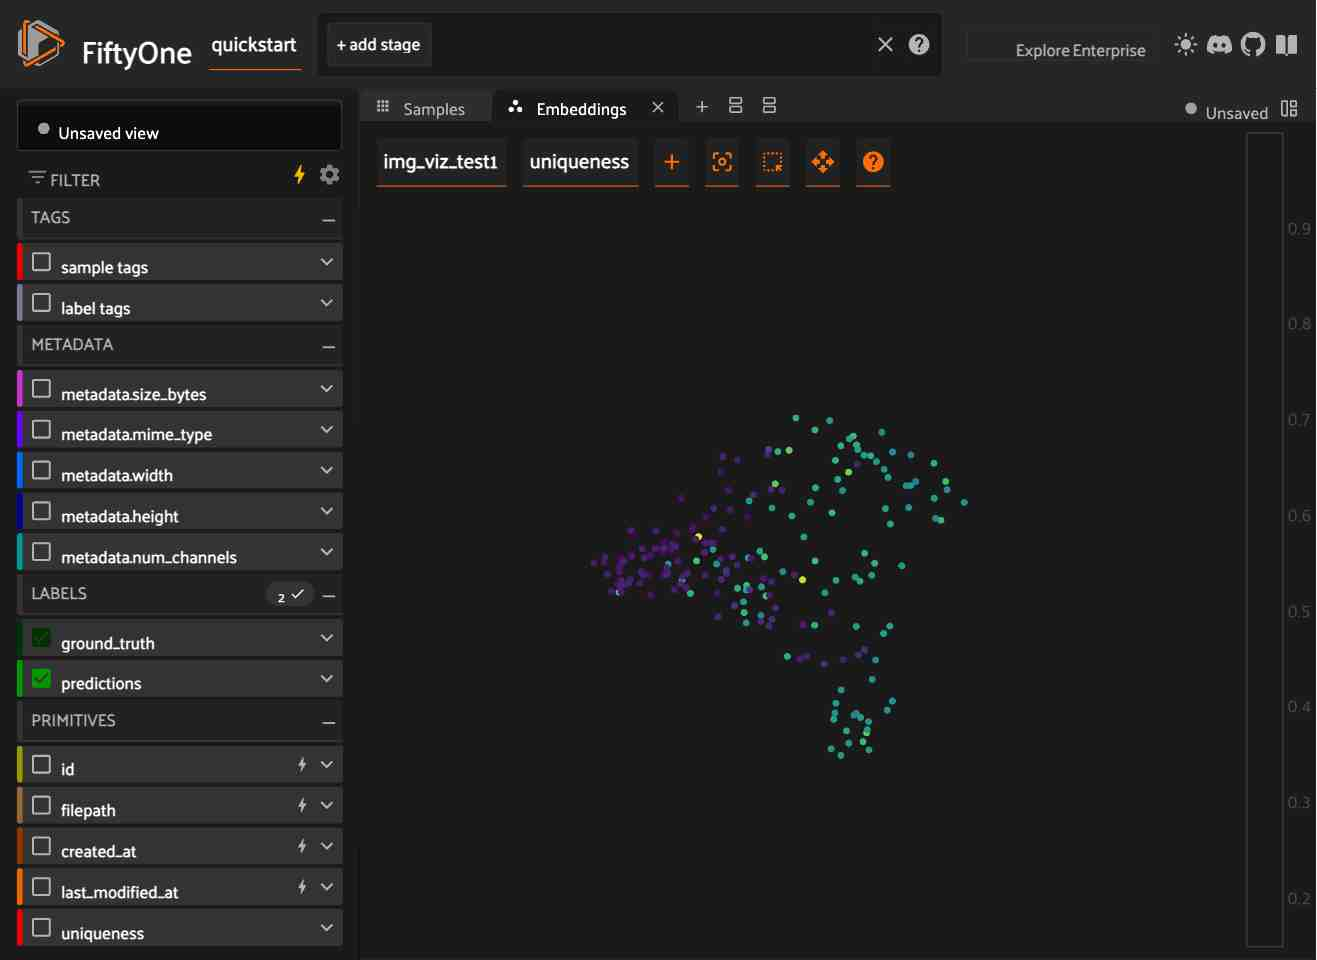

In [5]:
session = fo.launch_app(dataset)

In [4]:
fo.delete_dataset("quickstart")
fo.list_datasets()

['demo0424',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'test_raw_imgs']

In [5]:
dataset = foz.load_zoo_dataset("quickstart")
model = foz.load_zoo_model("clip-vit-base32-torch")

results = fob.compute_similarity(
    dataset,
    model=model,
    brain_key="img_sim_test1",
)

Dataset already downloaded
Loading 'quickstart'
 100% |█████████████████| 200/200 [1.4s elapsed, 0s remaining, 143.3 samples/s]         
Dataset 'quickstart' created
Computing embeddings...
 100% |█████████████████| 200/200 [5.9s elapsed, 0s remaining, 34.8 samples/s]       


In [6]:
info = dataset.get_brain_info("img_sim_test1")
print(info.config.supports_prompts)

None


In [8]:
session = fo.launch_app(dataset)

In [9]:
session.close()

Exception ignored in: <function Service.__del__ at 0x117901ee0>
Traceback (most recent call last):
  File "/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/core/service.py", line 86, in __del__
    self.stop()
  File "/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/fiftyone/core/service.py", line 129, in stop
    self.child.wait()
  File "/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/psutil/__init__.py", line 1359, in wait
    ret = super(Popen, self).wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/psutil/__init__.py", line 1268, in wait
    self._exitcode = self._proc.wait(timeout)
                     ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/psutil/_psosx.py", line 343, in wrapper
    return fun(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Use

In [11]:
fo.list_datasets()

['demo0424',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'quickstart',
 'test_raw_imgs']

In [3]:
import fiftyone.utils.random as four

# Load some COCO data
dataset = foz.load_zoo_dataset("coco-2017", split="test")

# Set up splits via tags
dataset.untag_samples(dataset.distinct("tags"))
four.random_split(dataset, {"train": 0.7, "test": 0.3})

Found test info at '/Users/bhc/fiftyone/coco-2017/raw/image_info_test2017.json'
Images already downloaded
Existing download of split 'test' is sufficient
Loading existing dataset 'coco-2017-test'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [5]:
model = foz.load_zoo_model("clip-vit-base32-torch")
embeddings = dataset.compute_embeddings(model)

 100% |█████████████| 40670/40670 [19.4m elapsed, 0s remaining, 35.1 samples/s]      


In [21]:
# Find leaks
index = fob.compute_leaky_splits(dataset, embeddings=embeddings, splits=["train", "test"])
leaks = index.leaks_view()

Computing duplicate samples...
Generating neighbors graph for 40670 embeddings...
Index complete
Generating neighbors graph for 34122 embeddings...
Index complete
Duplicates computation complete



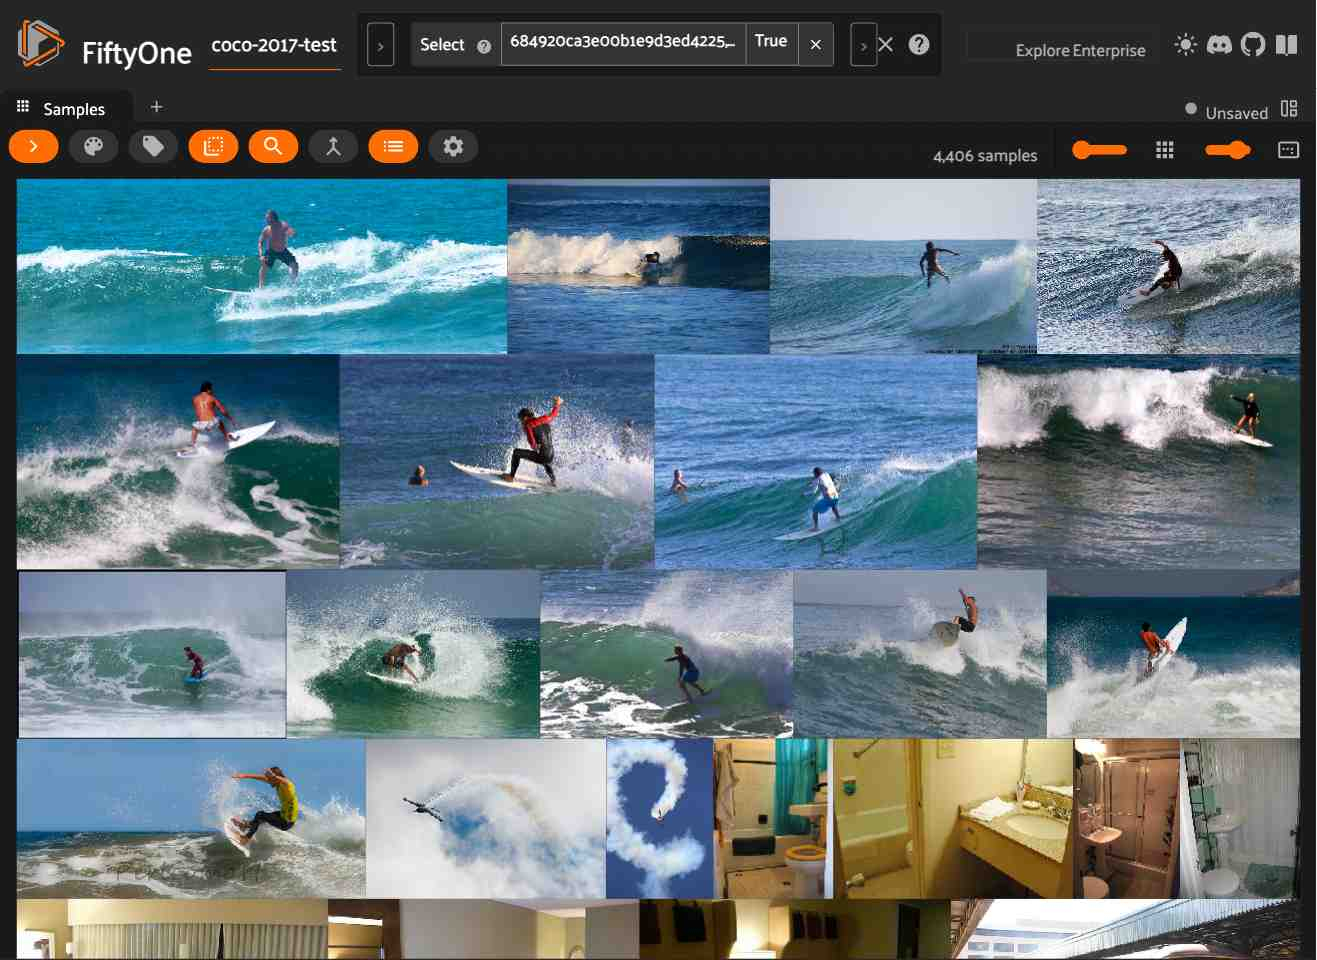

In [22]:
session = fo.launch_app(leaks)


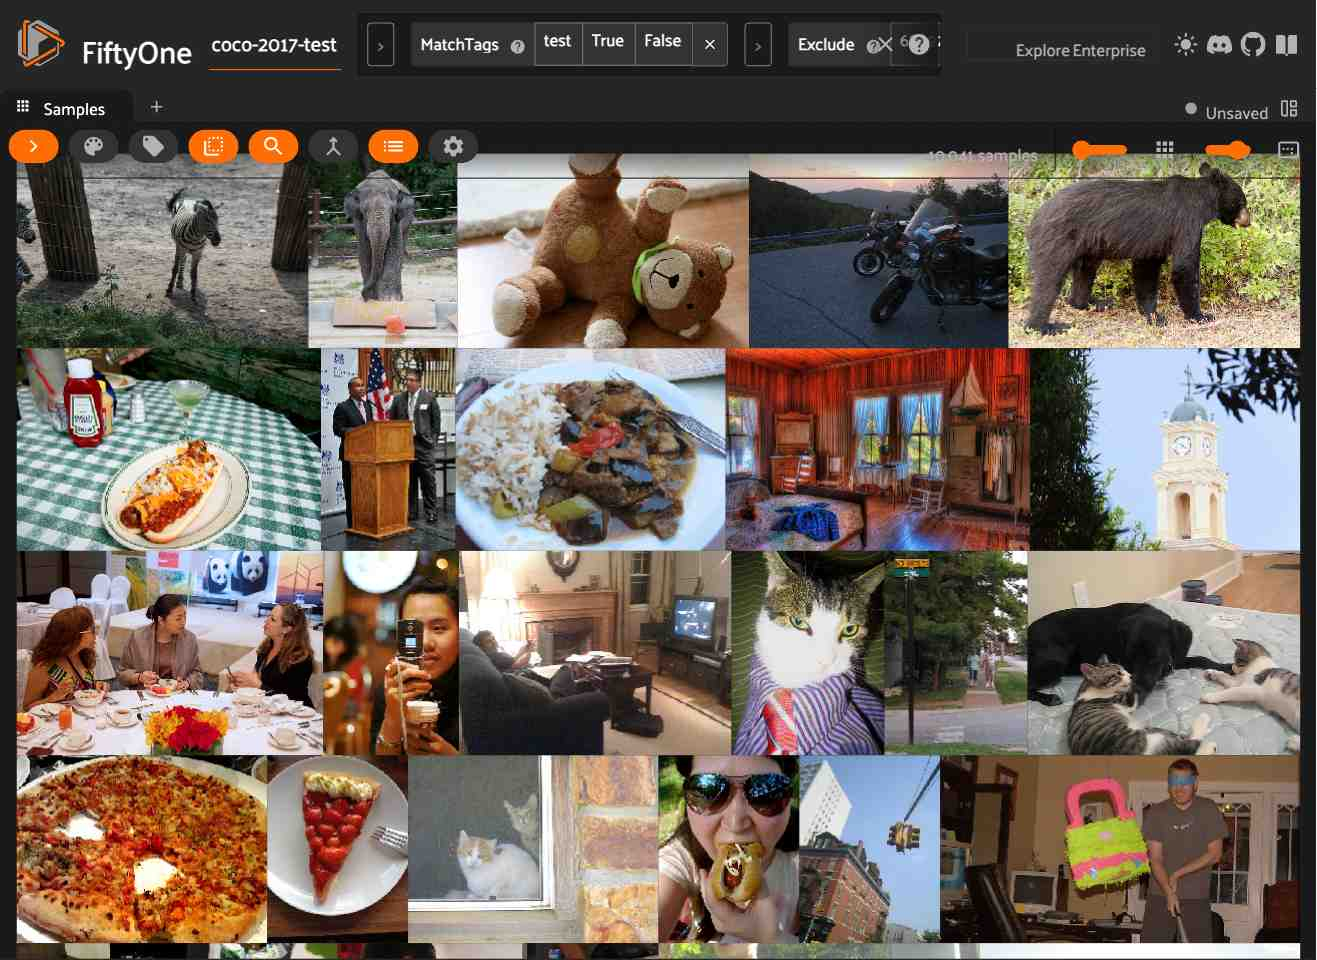

In [ ]:
# The original test split
test_set = index.split_views["test"]

# The test set with leaks removed
test_set_no_leaks = index.no_leaks_view(test_set)

session.view = test_set_no_leaks

In [26]:
session.close()

In [6]:
index = fob.compute_near_duplicates(dataset, embeddings=embeddings)

dups_view = index.duplicates_view(
    type_field="dup_type",
    id_field="dup_id",
    dist_field="dup_dist",
)
session = fo.launch_app(dups_view)

Computing duplicate samples...
Generating neighbors graph for 40670 embeddings...
Index complete
Generating neighbors graph for 34122 embeddings...
Index complete
Duplicates computation complete


In [7]:
index.find_unique(500)
print(index.unique_ids[:5])

Computing unique samples...
Generating neighbors graph for 40670 embeddings...
Index complete
threshold: 1.000000, kept: 9, target: 500
threshold: 0.500000, kept: 7250, target: 500
threshold: 0.750000, kept: 263, target: 500
threshold: 0.625000, kept: 1688, target: 500
threshold: 0.687500, kept: 676, target: 500
threshold: 0.718750, kept: 432, target: 500
threshold: 0.703125, kept: 551, target: 500
threshold: 0.710938, kept: 491, target: 500
threshold: 0.707031, kept: 521, target: 500
threshold: 0.708984, kept: 505, target: 500
threshold: 0.709961, kept: 496, target: 500
threshold: 0.709473, kept: 499, target: 500
threshold: 0.709229, kept: 503, target: 500
threshold: 0.709351, kept: 502, target: 500
threshold: 0.709412, kept: 500, target: 500
Uniqueness computation complete
['684920ca3e00b1e9d3ed41b1', '684920ca3e00b1e9d3ed41b2', '684920ca3e00b1e9d3ed41b3', '684920ca3e00b1e9d3ed41b4', '684920ca3e00b1e9d3ed41b5']


In [8]:
%matplotlib inline

viz_results = fob.compute_visualization(dataset, embeddings=embeddings)

# Visualize the unique samples in embeddings space
plot = index.visualize_unique(viz_results)
plot.show(height=800, yaxis_scaleanchor="x")

Generating visualization...
UMAP( verbose=True)
Wed Jun 11 18:16:52 2025 Construct fuzzy simplicial set
Wed Jun 11 18:16:52 2025 Finding Nearest Neighbors
Wed Jun 11 18:16:52 2025 Building RP forest with 15 trees


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Wed Jun 11 18:16:54 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Wed Jun 11 18:16:59 2025 Finished Nearest Neighbor Search
Wed Jun 11 18:17:00 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jun 11 18:17:06 2025 Finished embedding


FigureWidget({
    'data': [{'customdata': array(['684920ca3e00b1e9d3ed41bb', '684920ca3e00b1e9d3ed41c0',
                                   '684920ca3e00b1e9d3ed41c5', ..., '684920d03e00b1e9d3ede08c',
                                   '684920d03e00b1e9d3ede08d', '684920d03e00b1e9d3ede08e'], dtype=object),
              'hovertemplate': ('<b>label: %{text}</b><br>x, y ' ... ': %{customdata}<extra></extra>'),
              'line': {'color': '#3366CC'},
              'mode': 'markers',
              'name': 'other',
              'showlegend': True,
              'text': array(['other', 'other', 'other', ..., 'other', 'other', 'other'], dtype='<U5'),
              'type': 'scattergl',
              'uid': '257460ab-8840-4154-aef6-f2078c6e2824',
              'x': array([-0.74260294,  0.5044595 ,  3.2097132 , ..., -2.7931125 ,  8.090958  ,
                           1.3719367 ], dtype=float32),
              'y': array([-2.8140497 , -0.86060536, 15.80785   , ..., 13.676642  ,  2.411489  